# Analysis — Student Mental Health Dataset

Notebook ini melanjutkan analisis dari dataset **Student Mental Health** untuk kebutuhan **AI & Data Innovation Challenge**. Fokus analisisnya bukan untuk melakukan diagnosis medis, tetapi untuk membaca pola awal kondisi kesehatan mental mahasiswa berbasis data survei, terutama terkait **support gap**: mahasiswa yang memiliki indikasi masalah mental tetapi belum mencari bantuan profesional.

**Arah insight utama:**
- Prevalensi depression, anxiety, dan panic attack.
- Kombinasi beberapa indikasi mental health dalam satu responden.
- Gap antara mahasiswa yang memiliki indikasi masalah mental dan mahasiswa yang mencari bantuan profesional.
- Pola berdasarkan tahun studi, CGPA, gender, umur, dan jurusan/course.
- Rekomendasi pengembangan dashboard Smart Campus berbasis data.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

## 1. Load Dataset

Cell ini dibuat fleksibel supaya notebook tetap bisa dijalankan baik di environment lokal, Google Colab, maupun struktur folder `./dataset/`.

In [35]:
possible_paths = [
    Path('./dataset/Student Mental health.csv'),
    Path('./Student Mental health.csv'),
    Path('/mnt/data/Student Mental health.csv')
]

csv_path = None
for path in possible_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError('Dataset tidak ditemukan. Pastikan file "Student Mental health.csv" ada di folder dataset/ atau satu folder dengan notebook.')

raw_df = pd.read_csv(csv_path)
df = raw_df.copy()

print(f'Path dataset yang dipakai: {csv_path}')
print(f'Ukuran dataset: {df.shape[0]} baris dan {df.shape[1]} kolom')
display(df.head())

Path dataset yang dipakai: dataset\Student Mental health.csv
Ukuran dataset: 101 baris dan 11 kolom


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.00,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.00,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.00,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.00,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.00,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


## 2. Data Understanding Awal

Pada tahap ini kita melihat struktur data, tipe data, missing value, duplikasi, serta nilai unik pada setiap kolom. Ini penting karena dataset survei sering memiliki masalah inkonsistensi format, terutama pada data kategorikal.

In [36]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

None

In [37]:
data_quality_raw = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_pct': (df.isna().mean().values * 100).round(2),
    'unique_count': df.nunique(dropna=True).values
})

display(data_quality_raw)
print(f'Jumlah duplikasi baris penuh: {df.duplicated().sum()}')

,column,dtype,missing_count,missing_pct,unique_count
0,Timestamp,object,0,0.00,92
1,Choose your gender,object,0,0.00,2
2,Age,float64,1,0.99,7
3,What is your course?,object,0,0.00,49
4,Your current year of Study,object,0,0.00,7
5,What is your CGPA?,object,0,0.00,6
6,Marital status,object,0,0.00,2
7,Do you have Depression?,object,0,0.00,2
8,Do you have Anxiety?,object,0,0.00,2
9,Do you have Panic attack?,object,0,0.00,2


Jumlah duplikasi baris penuh: 0


In [38]:
# Melihat nilai unik tiap kolom agar proses cleaning lebih terarah
for column in df.columns:
    print('--' * 45)
    print(f"Kolom: {column}")
    print(f"Tipe data: {df[column].dtype}")
    print(f"Jumlah unique values: {df[column].nunique(dropna=True)}")
    print('Unique values:')
    print(df[column].dropna().unique())

------------------------------------------------------------------------------------------
Kolom: Timestamp
Tipe data: object
Jumlah unique values: 92
Unique values:
['8/7/2020 12:02' '8/7/2020 12:04' '8/7/2020 12:05' '8/7/2020 12:06'
 '8/7/2020 12:13' '8/7/2020 12:31' '8/7/2020 12:32' '8/7/2020 12:33'
 '8/7/2020 12:35' '8/7/2020 12:39' '8/7/2020 12:40' '8/7/2020 12:41'
 '8/7/2020 12:43' '8/7/2020 12:46' '8/7/2020 12:52' '8/7/2020 13:05'
 '8/7/2020 13:07' '8/7/2020 13:12' '8/7/2020 13:13' '8/7/2020 13:15'
 '8/7/2020 13:17' '8/7/2020 13:29' '8/7/2020 13:35' '8/7/2020 13:41'
 '8/7/2020 13:58' '8/7/2020 14:05' '8/7/2020 14:27' '8/7/2020 14:29'
 '8/7/2020 14:31' '8/7/2020 14:41' '8/7/2020 14:43' '8/7/2020 14:45'
 '8/7/2020 14:47' '8/7/2020 14:56' '8/7/2020 14:57' '8/7/2020 14:58'
 '8/7/2020 15:07' '8/7/2020 15:08' '8/7/2020 15:09' '8/7/2020 15:12'
 '8/7/2020 15:14' '8/7/2020 15:18' '8/7/2020 15:27' '8/7/2020 15:37'
 '8/7/2020 15:47' '8/7/2020 15:48' '8/7/2020 15:57' '8/7/2020 15:58'
 '8/7/

## 3. Data Cleaning & Standardisasi Kolom

Beberapa hal yang perlu dibersihkan:
- Nama kolom terlalu panjang sehingga perlu disederhanakan.
- Nilai kategorikal memiliki spasi tambahan, misalnya pada rentang CGPA.
- Tahun studi memiliki format huruf besar/kecil yang tidak seragam.
- Beberapa nama course/jurusan memiliki variasi penulisan.
- Kolom Yes/No perlu diubah menjadi angka 1/0 agar mudah dihitung.

In [39]:
# Rename kolom agar lebih mudah dianalisis
rename_map = {
    'Timestamp': 'timestamp',
    'Choose your gender': 'gender',
    'Age': 'age',
    'What is your course?': 'course',
    'Your current year of Study': 'year_study',
    'What is your CGPA?': 'cgpa',
    'Marital status': 'marital_status',
    'Do you have Depression?': 'depression',
    'Do you have Anxiety?': 'anxiety',
    'Do you have Panic attack?': 'panic_attack',
    'Did you seek any specialist for a treatment?': 'seek_specialist'
}

df_clean = df.rename(columns=rename_map).copy()

# Strip spasi pada semua kolom object
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Parsing timestamp
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')

# Standarisasi gender
df_clean['gender'] = df_clean['gender'].str.title()

# Standarisasi year study, contoh: year 1, Year 1 -> Year 1
df_clean['year_study'] = (
    df_clean['year_study']
    .str.lower()
    .str.extract(r'(\d+)')[0]
    .apply(lambda x: f'Year {x}' if pd.notna(x) else np.nan)
)

# Standarisasi CGPA
df_clean['cgpa'] = df_clean['cgpa'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Standarisasi course: lowercase, hapus spasi, lalu beberapa mapping sederhana
course_map = {
    'laws': 'law',
    'law': 'law',
    'islamic education': 'islamic education',
    'pendidikan islam': 'islamic education',
    'mathemathics': 'mathematics',
    'maths': 'mathematics',
    'bcs': 'computer science',
    'bit': 'information technology',
    'engin': 'engineering',
    'engineering': 'engineering',
    'psychology': 'psychology'
}

df_clean['course_clean'] = (
    df_clean['course']
    .str.lower()
    .str.strip()
    .replace(course_map)
    .str.title()
)

# Ubah Yes/No menjadi 1/0
binary_cols = ['marital_status', 'depression', 'anxiety', 'panic_attack', 'seek_specialist']
for col in binary_cols:
    df_clean[col] = df_clean[col].str.title().map({'Yes': 1, 'No': 0})

# Pastikan age numerik
df_clean['age'] = pd.to_numeric(df_clean['age'], errors='coerce')

# Buat urutan kategorikal agar visualisasi lebih rapi
cgpa_order = ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00']
year_order = ['Year 1', 'Year 2', 'Year 3', 'Year 4']

df_clean['cgpa'] = pd.Categorical(df_clean['cgpa'], categories=cgpa_order, ordered=True)
df_clean['year_study'] = pd.Categorical(df_clean['year_study'], categories=year_order, ordered=True)

display(df_clean.head())

,timestamp,gender,age,course,year_study,cgpa,marital_status,depression,anxiety,panic_attack,seek_specialist,course_clean
0,2020-08-07 12:02:00,Female,18.00,Engineering,Year 1,3.00 - 3.49,0,1,0,1,0,Engineering
1,2020-08-07 12:04:00,Male,21.00,Islamic education,Year 2,3.00 - 3.49,0,0,1,0,0,Islamic Education
2,2020-08-07 12:05:00,Male,19.00,BIT,Year 1,3.00 - 3.49,0,1,1,1,0,Information Technology
3,2020-08-07 12:06:00,Female,22.00,Laws,Year 3,3.00 - 3.49,1,1,0,0,0,Law
4,2020-08-07 12:13:00,Male,23.00,Mathemathics,Year 4,3.00 - 3.49,0,0,0,0,0,Mathematics


In [40]:
cleaning_summary = pd.DataFrame({
    'column': df_clean.columns,
    'dtype_after_cleaning': df_clean.dtypes.astype(str).values,
    'missing_count': df_clean.isna().sum().values,
    'missing_pct': (df_clean.isna().mean().values * 100).round(2),
    'unique_count': df_clean.nunique(dropna=True).values
})

display(cleaning_summary)

,column,dtype_after_cleaning,missing_count,missing_pct,unique_count
0,timestamp,datetime64[ns],23,22.77,69
1,gender,object,0,0.00,2
2,age,float64,1,0.99,7
3,course,object,0,0.00,48
4,year_study,category,0,0.00,4
5,cgpa,category,0,0.00,5
6,marital_status,int64,0,0.00,2
7,depression,int64,0,0.00,2
8,anxiety,int64,0,0.00,2
9,panic_attack,int64,0,0.00,2


## 4. Feature Engineering untuk Analisis

Kita membuat beberapa kolom turunan agar insight lebih kuat:
- `issue_count`: jumlah indikasi mental health yang dijawab Yes dari depression, anxiety, dan panic attack.
- `has_any_issue`: apakah mahasiswa memiliki minimal satu indikasi.
- `multiple_issue`: apakah mahasiswa memiliki dua atau lebih indikasi.
- `support_status`: segmentasi support gap.
- `risk_group`: kelompok kompleksitas indikasi.

Catatan: label ini hanya untuk kebutuhan analisis data, bukan diagnosis medis.

In [41]:
mental_issue_cols = ['depression', 'anxiety', 'panic_attack']

df_clean['issue_count'] = df_clean[mental_issue_cols].sum(axis=1)
df_clean['has_any_issue'] = (df_clean['issue_count'] > 0).astype(int)
df_clean['multiple_issue'] = (df_clean['issue_count'] >= 2).astype(int)
df_clean['all_three_issues'] = (df_clean['issue_count'] == 3).astype(int)

df_clean['support_status'] = np.select(
    [
        df_clean['issue_count'].eq(0),
        df_clean['seek_specialist'].eq(1)
    ],
    [
        'Stable / No Reported Indicator',
        'Reached Support'
    ],
    default='Silent Struggle'
)

df_clean['risk_group'] = pd.cut(
    df_clean['issue_count'],
    bins=[-1, 0, 1, 3],
    labels=['Low / No Indicator', 'Single Indicator', 'Multiple Indicators']
)

# Untuk analisis umur sederhana
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 18, 20, 22, 100],
    labels=['<=18', '19-20', '21-22', '23+']
)

selected_cols = [
    'gender', 'age', 'age_group', 'course_clean', 'year_study', 'cgpa',
    'depression', 'anxiety', 'panic_attack', 'seek_specialist',
    'issue_count', 'risk_group', 'support_status'
]
display(df_clean[selected_cols].head(10))

,gender,age,age_group,course_clean,year_study,cgpa,depression,anxiety,panic_attack,seek_specialist,issue_count,risk_group,support_status
0,Female,18.00,<=18,Engineering,Year 1,3.00 - 3.49,1,0,1,0,2,Multiple Indicators,Silent Struggle
1,Male,21.00,21-22,Islamic Education,Year 2,3.00 - 3.49,0,1,0,0,1,Single Indicator,Silent Struggle
2,Male,19.00,19-20,Information Technology,Year 1,3.00 - 3.49,1,1,1,0,3,Multiple Indicators,Silent Struggle
3,Female,22.00,21-22,Law,Year 3,3.00 - 3.49,1,0,0,0,1,Single Indicator,Silent Struggle
4,Male,23.00,23+,Mathematics,Year 4,3.00 - 3.49,0,0,0,0,0,Low / No Indicator,Stable / No Reported Indicator
5,Male,19.00,19-20,Engineering,Year 2,3.50 - 4.00,0,0,1,0,1,Single Indicator,Silent Struggle
6,Female,23.00,23+,Islamic Education,Year 2,3.50 - 4.00,1,0,1,0,2,Multiple Indicators,Silent Struggle
7,Female,18.00,<=18,Computer Science,Year 1,3.50 - 4.00,0,1,0,0,1,Single Indicator,Silent Struggle
8,Female,19.00,19-20,Human Resources,Year 2,2.50 - 2.99,0,0,0,0,0,Low / No Indicator,Stable / No Reported Indicator
9,Male,18.00,<=18,Irkhs,Year 1,3.50 - 4.00,0,1,1,0,2,Multiple Indicators,Silent Struggle


## 5. Ringkasan Kondisi Mental Health Secara Umum

Analisis pertama melihat seberapa banyak responden yang melaporkan depression, anxiety, dan panic attack. Tahap ini berguna untuk melihat indikator mana yang paling dominan dalam dataset.

,indicator,count_yes,percentage_yes
0,Depression,35,34.65
1,Anxiety,34,33.66
2,Panic Attack,33,32.67


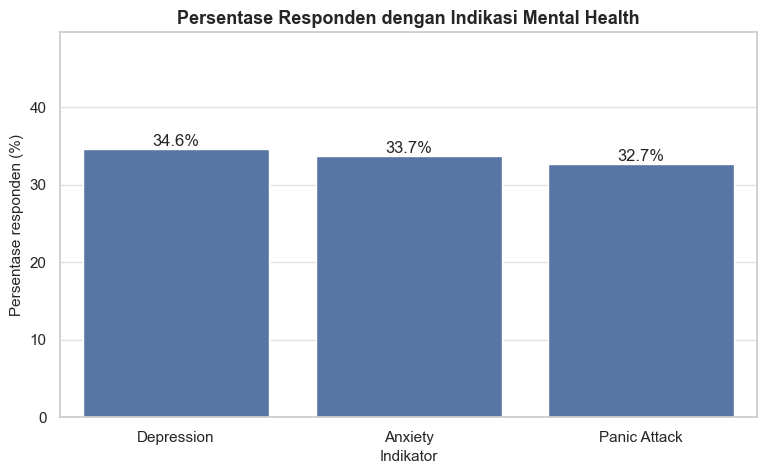

In [42]:
indicator_summary = pd.DataFrame({
    'indicator': ['Depression', 'Anxiety', 'Panic Attack'],
    'count_yes': [df_clean['depression'].sum(), df_clean['anxiety'].sum(), df_clean['panic_attack'].sum()],
})
indicator_summary['percentage_yes'] = (indicator_summary['count_yes'] / len(df_clean) * 100).round(2)

display(indicator_summary)

ax = sns.barplot(data=indicator_summary, x='indicator', y='percentage_yes', color='#4C72B0')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Persentase Responden dengan Indikasi Mental Health')
plt.xlabel('Indikator')
plt.ylabel('Persentase responden (%)')
plt.ylim(0, max(indicator_summary['percentage_yes']) + 15)
plt.show()

### Insight sementara

Apabila ketiga indikator memiliki persentase yang relatif berdekatan, artinya isu kesehatan mental pada dataset tidak hanya terkonsentrasi pada satu bentuk kondisi saja. Kampus perlu melihat depression, anxiety, dan panic attack sebagai indikator yang saling terkait, bukan sebagai masalah yang sepenuhnya terpisah.

## 6. Analisis Kompleksitas Indikasi: 0, 1, 2, atau 3 Indikasi

Analisis ini melihat apakah responden hanya memiliki satu indikasi atau beberapa indikasi sekaligus. Ini penting karena mahasiswa dengan beberapa indikasi sekaligus dapat membutuhkan perhatian yang lebih terstruktur.

,issue_count,count,percentage
0,0,37,36.63
1,1,36,35.64
2,2,18,17.82
3,3,10,9.90


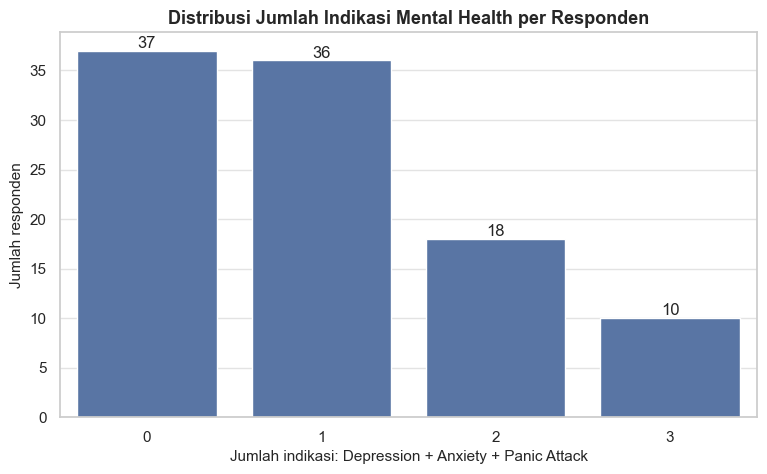

In [43]:
issue_count_summary = (
    df_clean['issue_count']
    .value_counts()
    .sort_index()
    .rename_axis('issue_count')
    .reset_index(name='count')
)
issue_count_summary['percentage'] = (issue_count_summary['count'] / len(df_clean) * 100).round(2)

display(issue_count_summary)

ax = sns.barplot(data=issue_count_summary, x='issue_count', y='count', color='#4C72B0')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribusi Jumlah Indikasi Mental Health per Responden')
plt.xlabel('Jumlah indikasi: Depression + Anxiety + Panic Attack')
plt.ylabel('Jumlah responden')
plt.show()

## 7. Analisis Kombinasi Indikasi / Co-occurrence

Di bagian ini, kita melihat kombinasi kondisi yang muncul bersamaan. Analisis ini lebih informatif dibanding hanya menghitung depression, anxiety, dan panic attack secara terpisah.

,combination,count,percentage
0,No Indicator,37,36.63
1,Anxiety,13,12.87
2,Panic Attack,13,12.87
3,Depression + Anxiety + Panic Attack,10,9.90
4,Depression,10,9.90
5,Depression + Anxiety,8,7.92
6,Depression + Panic Attack,7,6.93
7,Anxiety + Panic Attack,3,2.97


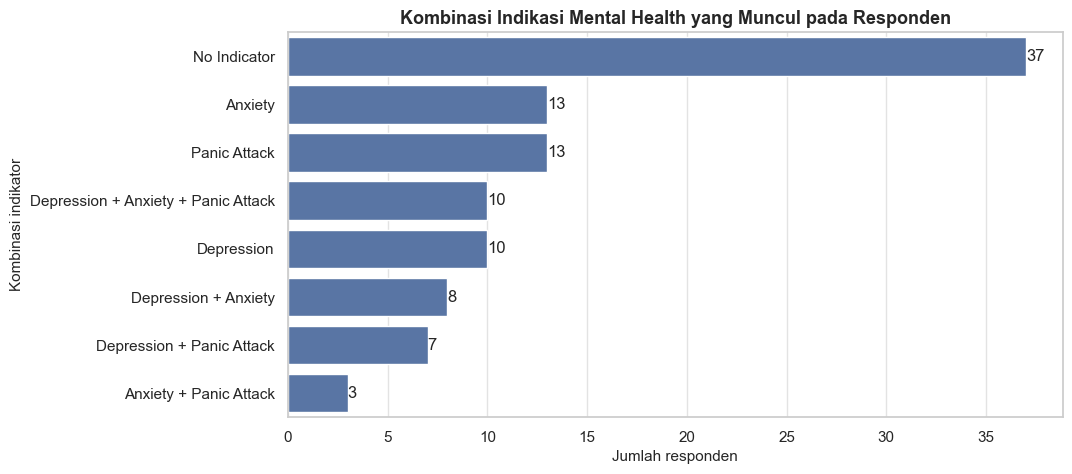

In [44]:
def combination_label(row):
    active = []
    if row['depression'] == 1:
        active.append('Depression')
    if row['anxiety'] == 1:
        active.append('Anxiety')
    if row['panic_attack'] == 1:
        active.append('Panic Attack')
    return 'No Indicator' if len(active) == 0 else ' + '.join(active)

df_clean['indicator_combination'] = df_clean.apply(combination_label, axis=1)

combination_summary = (
    df_clean['indicator_combination']
    .value_counts()
    .rename_axis('combination')
    .reset_index(name='count')
)
combination_summary['percentage'] = (combination_summary['count'] / len(df_clean) * 100).round(2)

display(combination_summary)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=combination_summary, y='combination', x='count', color='#4C72B0')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Kombinasi Indikasi Mental Health yang Muncul pada Responden')
plt.xlabel('Jumlah responden')
plt.ylabel('Kombinasi indikator')
plt.show()

,depression,anxiety,panic_attack,seek_specialist,issue_count
depression,1.00,0.27,0.25,0.35,0.74
anxiety,0.27,1.00,0.08,0.09,0.66
panic_attack,0.25,0.08,1.00,0.18,0.65
seek_specialist,0.35,0.09,0.18,1.00,0.30
issue_count,0.74,0.66,0.65,0.30,1.00


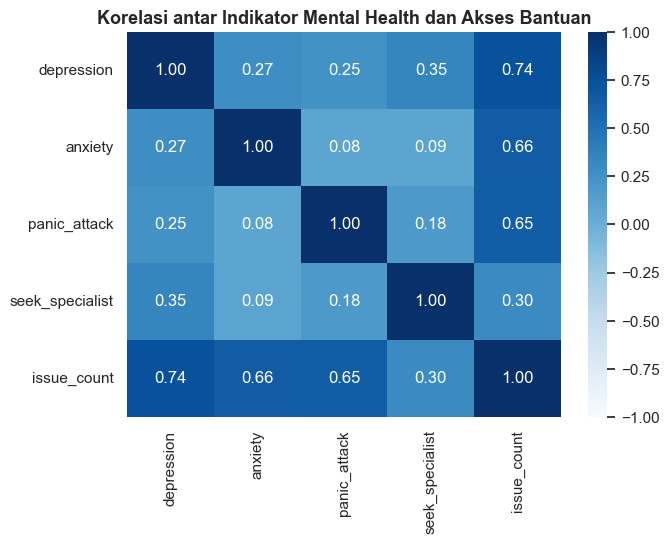

In [45]:
# Korelasi sederhana antar indikator mental health dan pencarian bantuan
corr_cols = ['depression', 'anxiety', 'panic_attack', 'seek_specialist', 'issue_count']
corr_matrix = df_clean[corr_cols].corr()

display(corr_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', vmin=-1, vmax=1)
plt.title('Korelasi antar Indikator Mental Health dan Akses Bantuan')
plt.show()

## 8. Analisis Support Gap

Bagian ini merupakan analisis utama. Kita ingin mengetahui berapa banyak mahasiswa yang memiliki minimal satu indikasi mental health, tetapi belum mencari bantuan profesional. Inilah yang disebut sebagai **Silent Struggle** dalam analisis ini.

In [46]:
total_students = len(df_clean)
with_issue = int(df_clean['has_any_issue'].sum())
without_issue = total_students - with_issue
silent_struggle = int(((df_clean['has_any_issue'] == 1) & (df_clean['seek_specialist'] == 0)).sum())
reached_support = int(((df_clean['has_any_issue'] == 1) & (df_clean['seek_specialist'] == 1)).sum())
support_gap_pct = silent_struggle / with_issue * 100 if with_issue > 0 else 0

support_gap_summary = pd.DataFrame({
    'metric': [
        'Total responden',
        'Memiliki minimal 1 indikasi mental health',
        'Tidak memiliki indikasi mental health',
        'Memiliki indikasi tetapi belum mencari bantuan profesional',
        'Memiliki indikasi dan sudah mencari bantuan profesional',
        'Support gap among at-risk respondents (%)'
    ],
    'value': [
        total_students,
        with_issue,
        without_issue,
        silent_struggle,
        reached_support,
        round(support_gap_pct, 2)
    ]
})

display(support_gap_summary)

display(Markdown(
    f'''
**Insight utama:** Dari **{with_issue}** responden yang memiliki minimal satu indikasi mental health, sebanyak **{silent_struggle}** responden belum mencari bantuan profesional. Artinya, terdapat support gap sebesar **{support_gap_pct:.1f}%** pada kelompok responden yang sudah menunjukkan indikasi masalah mental.
'''
))

,metric,value
0,Total responden,101.00
1,Memiliki minimal 1 indikasi mental health,64.00
2,Tidak memiliki indikasi mental health,37.00
3,Memiliki indikasi tetapi belum mencari bantuan...,58.00
4,Memiliki indikasi dan sudah mencari bantuan pr...,6.00
5,Support gap among at-risk respondents (%),90.62



**Insight utama:** Dari **64** responden yang memiliki minimal satu indikasi mental health, sebanyak **58** responden belum mencari bantuan profesional. Artinya, terdapat support gap sebesar **90.6%** pada kelompok responden yang sudah menunjukkan indikasi masalah mental.


,support_status,count,percentage
0,Silent Struggle,58,57.43
1,Stable / No Reported Indicator,37,36.63
2,Reached Support,6,5.94


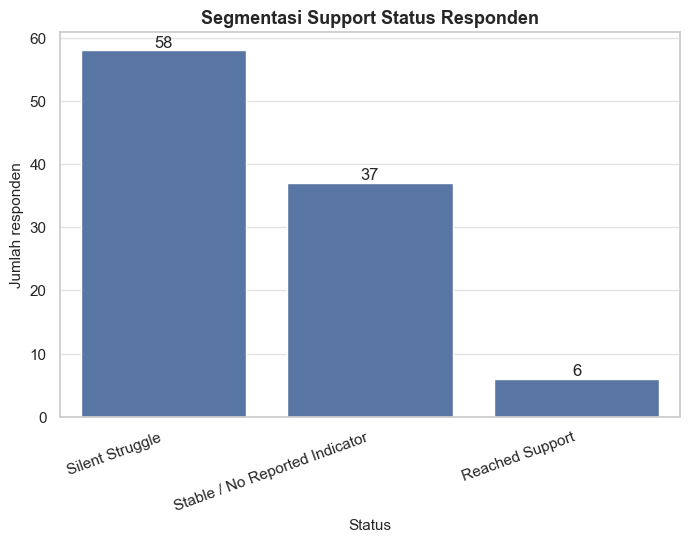

In [47]:
support_status_summary = (
    df_clean['support_status']
    .value_counts()
    .rename_axis('support_status')
    .reset_index(name='count')
)
support_status_summary['percentage'] = (support_status_summary['count'] / len(df_clean) * 100).round(2)

display(support_status_summary)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=support_status_summary, x='support_status', y='count', color='#4C72B0')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Segmentasi Support Status Responden')
plt.xlabel('Status')
plt.ylabel('Jumlah responden')
plt.xticks(rotation=20, ha='right')
plt.show()

## 9. Support Gap Berdasarkan Jumlah Indikasi

Analisis ini melihat apakah mahasiswa dengan jumlah indikasi yang lebih banyak cenderung mencari bantuan profesional atau tetap belum tersambung dengan bantuan. Ini penting untuk merancang prioritas intervensi kampus.

,issue_count,total,seek_support,not_seek_support,seek_support_pct,not_seek_support_pct
0,0,37,0,37,0.00,100.00
1,1,36,0,36,0.00,100.00
2,2,18,5,13,27.78,72.22
3,3,10,1,9,10.00,90.00


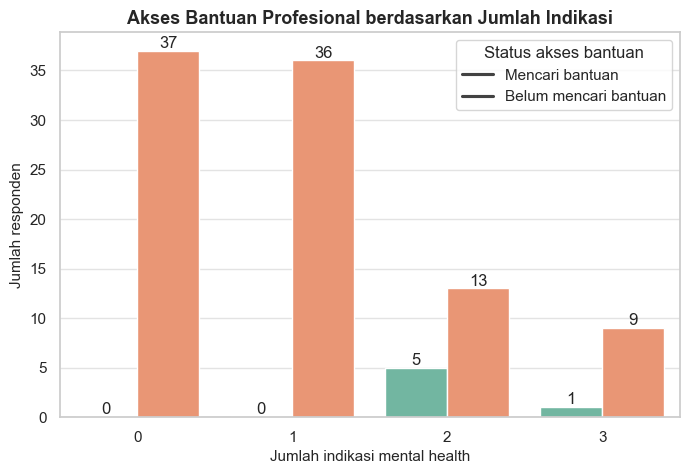

In [48]:
support_by_issue_count = (
    df_clean
    .groupby('issue_count', observed=True)
    .agg(
        total=('issue_count', 'size'),
        seek_support=('seek_specialist', 'sum')
    )
    .reset_index()
)
support_by_issue_count['not_seek_support'] = support_by_issue_count['total'] - support_by_issue_count['seek_support']
support_by_issue_count['seek_support_pct'] = (support_by_issue_count['seek_support'] / support_by_issue_count['total'] * 100).round(2)
support_by_issue_count['not_seek_support_pct'] = (support_by_issue_count['not_seek_support'] / support_by_issue_count['total'] * 100).round(2)

display(support_by_issue_count)

plot_df = support_by_issue_count.melt(
    id_vars='issue_count',
    value_vars=['seek_support', 'not_seek_support'],
    var_name='support_action',
    value_name='count'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=plot_df, x='issue_count', y='count', hue='support_action', palette='Set2')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Akses Bantuan Profesional berdasarkan Jumlah Indikasi')
plt.xlabel('Jumlah indikasi mental health')
plt.ylabel('Jumlah responden')
plt.legend(title='Status akses bantuan', labels=['Mencari bantuan', 'Belum mencari bantuan'])
plt.show()

## 10. Analisis berdasarkan Tahun Studi

Tahun studi dapat menjadi konteks penting karena fase akademik mahasiswa berbeda-beda. Tahun awal biasanya berkaitan dengan adaptasi, sedangkan tahun tengah/akhir dapat berkaitan dengan beban akademik, organisasi, magang, atau persiapan karier.

,year_study,total,with_any_issue,multiple_issue,silent_struggle,seek_support,avg_issue_count,any_issue_pct,silent_struggle_pct,seek_support_pct
0,Year 1,43,25,13,22,3,0.98,58.14,51.16,6.98
1,Year 2,26,19,7,17,2,1.08,73.08,65.38,7.69
2,Year 3,24,18,7,17,1,1.17,75.00,70.83,4.17
3,Year 4,8,2,1,2,0,0.50,25.00,25.00,0.00


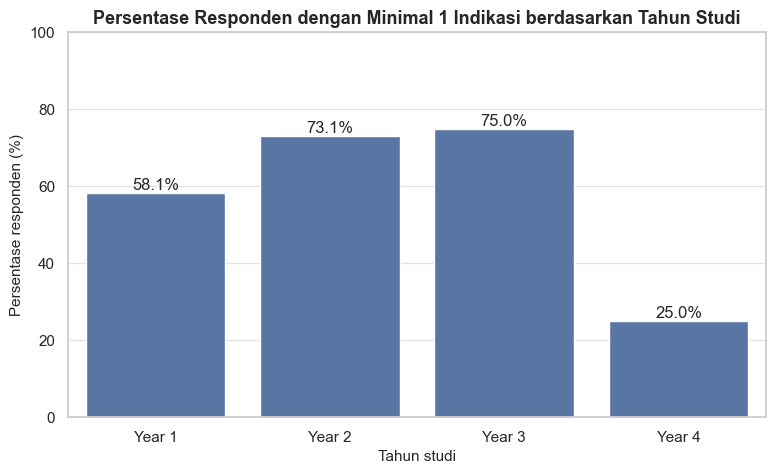

In [49]:
year_summary = (
    df_clean
    .groupby('year_study', observed=True)
    .agg(
        total=('year_study', 'size'),
        with_any_issue=('has_any_issue', 'sum'),
        multiple_issue=('multiple_issue', 'sum'),
        silent_struggle=('support_status', lambda s: (s == 'Silent Struggle').sum()),
        seek_support=('seek_specialist', 'sum'),
        avg_issue_count=('issue_count', 'mean')
    )
    .reset_index()
)
year_summary['any_issue_pct'] = (year_summary['with_any_issue'] / year_summary['total'] * 100).round(2)
year_summary['silent_struggle_pct'] = (year_summary['silent_struggle'] / year_summary['total'] * 100).round(2)
year_summary['seek_support_pct'] = (year_summary['seek_support'] / year_summary['total'] * 100).round(2)
year_summary['avg_issue_count'] = year_summary['avg_issue_count'].round(2)

display(year_summary)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=year_summary, x='year_study', y='any_issue_pct', color='#4C72B0')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Persentase Responden dengan Minimal 1 Indikasi berdasarkan Tahun Studi')
plt.xlabel('Tahun studi')
plt.ylabel('Persentase responden (%)')
plt.ylim(0, 100)
plt.show()

support_status,Reached Support,Silent Struggle,Stable / No Reported Indicator
year_study,,,
Year 1,6.98,51.16,41.86
Year 2,7.69,65.38,26.92
Year 3,4.17,70.83,25.00
Year 4,0.00,25.00,75.00


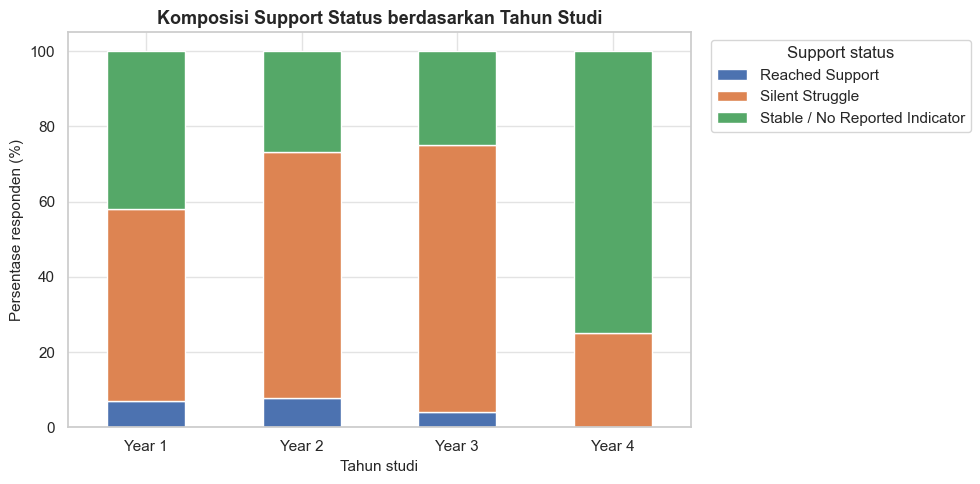

In [50]:
year_status = pd.crosstab(
    df_clean['year_study'],
    df_clean['support_status'],
    normalize='index'
).mul(100).round(2)

display(year_status)

year_status.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Komposisi Support Status berdasarkan Tahun Studi')
plt.xlabel('Tahun studi')
plt.ylabel('Persentase responden (%)')
plt.xticks(rotation=0)
plt.legend(title='Support status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 11. Analisis berdasarkan CGPA

Analisis ini tidak dimaksudkan untuk menyimpulkan bahwa nilai menyebabkan kondisi mental tertentu. Tujuannya adalah melihat apakah mahasiswa dengan performa akademik yang berbeda tetap dapat menunjukkan indikasi mental health. Ini berguna agar kampus tidak hanya memantau mahasiswa dari angka akademik.

,cgpa,total,with_any_issue,multiple_issue,silent_struggle,seek_support,avg_issue_count,any_issue_pct,silent_struggle_pct,seek_support_pct
0,0 - 1.99,4,1,0,1,0,0.25,25.00,25.00,0.00
1,2.00 - 2.49,2,1,0,1,0,0.50,50.00,50.00,0.00
2,2.50 - 2.99,4,3,3,1,2,1.75,75.00,25.00,50.00
3,3.00 - 3.49,43,28,11,28,0,1.00,65.12,65.12,0.00
4,3.50 - 4.00,48,31,14,27,4,1.04,64.58,56.25,8.33


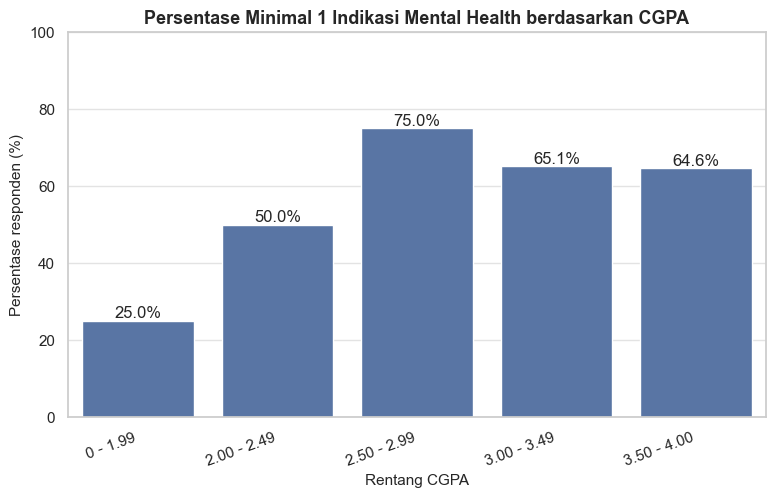

In [51]:
cgpa_summary = (
    df_clean
    .groupby('cgpa', observed=True)
    .agg(
        total=('cgpa', 'size'),
        with_any_issue=('has_any_issue', 'sum'),
        multiple_issue=('multiple_issue', 'sum'),
        silent_struggle=('support_status', lambda s: (s == 'Silent Struggle').sum()),
        seek_support=('seek_specialist', 'sum'),
        avg_issue_count=('issue_count', 'mean')
    )
    .reset_index()
)
cgpa_summary['any_issue_pct'] = (cgpa_summary['with_any_issue'] / cgpa_summary['total'] * 100).round(2)
cgpa_summary['silent_struggle_pct'] = (cgpa_summary['silent_struggle'] / cgpa_summary['total'] * 100).round(2)
cgpa_summary['seek_support_pct'] = (cgpa_summary['seek_support'] / cgpa_summary['total'] * 100).round(2)
cgpa_summary['avg_issue_count'] = cgpa_summary['avg_issue_count'].round(2)

display(cgpa_summary)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=cgpa_summary, x='cgpa', y='any_issue_pct', color='#4C72B0')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Persentase Minimal 1 Indikasi Mental Health berdasarkan CGPA')
plt.xlabel('Rentang CGPA')
plt.ylabel('Persentase responden (%)')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 100)
plt.show()

## 12. Analisis berdasarkan Gender

Dataset ini perlu dibaca hati-hati karena distribusi gender tidak seimbang. Tujuan analisis gender di sini bukan untuk membuat klaim generalisasi besar, tetapi untuk melihat gambaran awal pada dataset.

,gender,total,depression_rate,anxiety_rate,panic_attack_rate,any_issue_rate,multiple_issue_rate,silent_struggle_rate,seek_support_rate
0,Female,75,38.67,32.00,33.33,64.00,28.00,57.33,6.67
1,Male,26,23.08,38.46,30.77,61.54,26.92,57.69,3.85


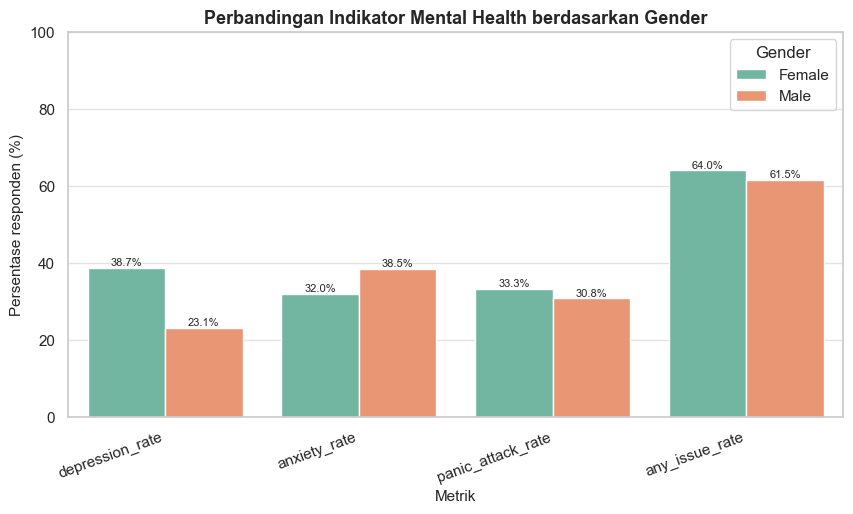

In [52]:
gender_summary = (
    df_clean
    .groupby('gender', observed=True)
    .agg(
        total=('gender', 'size'),
        depression_rate=('depression', 'mean'),
        anxiety_rate=('anxiety', 'mean'),
        panic_attack_rate=('panic_attack', 'mean'),
        any_issue_rate=('has_any_issue', 'mean'),
        multiple_issue_rate=('multiple_issue', 'mean'),
        silent_struggle_rate=('support_status', lambda s: (s == 'Silent Struggle').mean()),
        seek_support_rate=('seek_specialist', 'mean')
    )
    .reset_index()
)

rate_cols = [c for c in gender_summary.columns if c.endswith('_rate')]
gender_summary[rate_cols] = (gender_summary[rate_cols] * 100).round(2)

display(gender_summary)

gender_plot = gender_summary.melt(
    id_vars=['gender', 'total'],
    value_vars=['depression_rate', 'anxiety_rate', 'panic_attack_rate', 'any_issue_rate'],
    var_name='metric',
    value_name='percentage'
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=gender_plot, x='metric', y='percentage', hue='gender', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)
plt.title('Perbandingan Indikator Mental Health berdasarkan Gender')
plt.xlabel('Metrik')
plt.ylabel('Persentase responden (%)')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 100)
plt.legend(title='Gender')
plt.show()

## 13. Analisis berdasarkan Umur

Karena rentang umur pada dataset cukup sempit, analisis umur sebaiknya dibaca sebagai eksplorasi awal saja.

,age_group,total,with_any_issue,multiple_issue,silent_struggle,avg_issue_count,any_issue_pct,silent_struggle_pct
0,<=18,32,22,10,20,1.06,68.75,62.50
1,19-20,27,17,9,16,1.11,62.96,59.26
2,21-22,5,3,0,3,0.60,60.00,60.00
3,23+,36,22,9,19,0.97,61.11,52.78


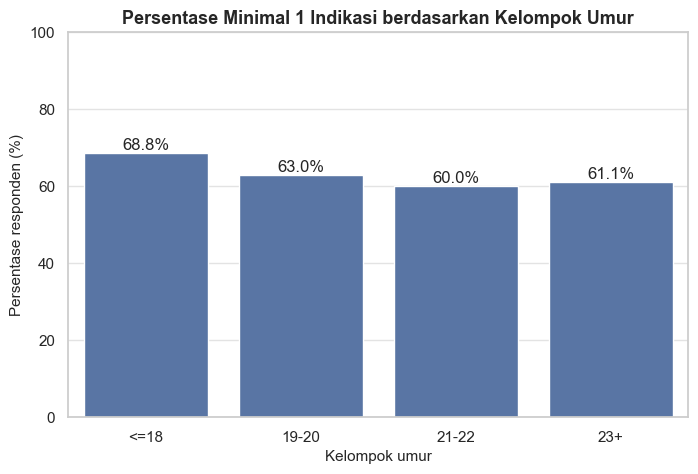

In [53]:
age_summary = (
    df_clean
    .groupby('age_group', observed=True)
    .agg(
        total=('age_group', 'size'),
        with_any_issue=('has_any_issue', 'sum'),
        multiple_issue=('multiple_issue', 'sum'),
        silent_struggle=('support_status', lambda s: (s == 'Silent Struggle').sum()),
        avg_issue_count=('issue_count', 'mean')
    )
    .reset_index()
)
age_summary['any_issue_pct'] = (age_summary['with_any_issue'] / age_summary['total'] * 100).round(2)
age_summary['silent_struggle_pct'] = (age_summary['silent_struggle'] / age_summary['total'] * 100).round(2)
age_summary['avg_issue_count'] = age_summary['avg_issue_count'].round(2)

display(age_summary)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=age_summary, x='age_group', y='any_issue_pct', color='#4C72B0')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Persentase Minimal 1 Indikasi berdasarkan Kelompok Umur')
plt.xlabel('Kelompok umur')
plt.ylabel('Persentase responden (%)')
plt.ylim(0, 100)
plt.show()

## 14. Analisis berdasarkan Course/Jurusan

Analisis course perlu sangat hati-hati karena jumlah responden per course banyak yang kecil. Karena itu, visualisasi difokuskan pada course dengan jumlah responden terbanyak dan course yang memiliki minimal jumlah data tertentu.

,course_clean,total
0,Engineering,18
1,Computer Science,18
2,Information Technology,10
3,Koe,6
4,Islamic Education,5
5,Biomedical Science,4
6,Psychology,3
7,Law,3
8,Benl,3
9,Engine,2


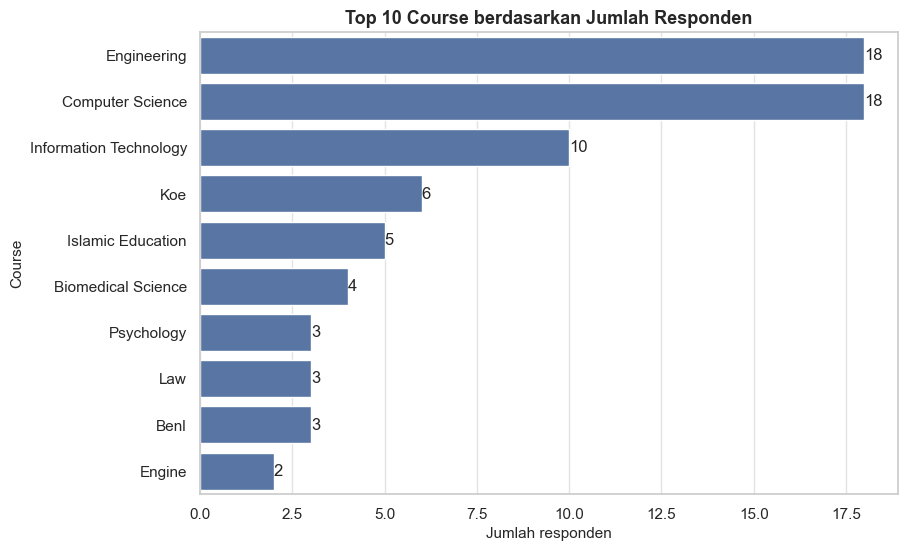

In [54]:
course_counts = (
    df_clean['course_clean']
    .value_counts()
    .rename_axis('course_clean')
    .reset_index(name='total')
)

display(course_counts.head(15))

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=course_counts.head(10), y='course_clean', x='total', color='#4C72B0')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Top 10 Course berdasarkan Jumlah Responden')
plt.xlabel('Jumlah responden')
plt.ylabel('Course')
plt.show()

,course_clean,total,with_any_issue,silent_struggle,avg_issue_count,any_issue_pct,silent_struggle_pct
28,Law,3,3,3,1.33,100.00,100.00
20,Information Technology,10,9,8,1.70,90.00,80.00
26,Koe,6,5,5,1.33,83.33,83.33
14,Engineering,18,12,11,0.94,66.67,61.11
3,Benl,3,2,2,1.00,66.67,66.67
34,Psychology,3,2,1,1.67,66.67,33.33
8,Computer Science,18,11,9,0.89,61.11,50.00
22,Islamic Education,5,2,2,0.60,40.00,40.00
4,Biomedical Science,4,0,0,0.00,0.00,0.00


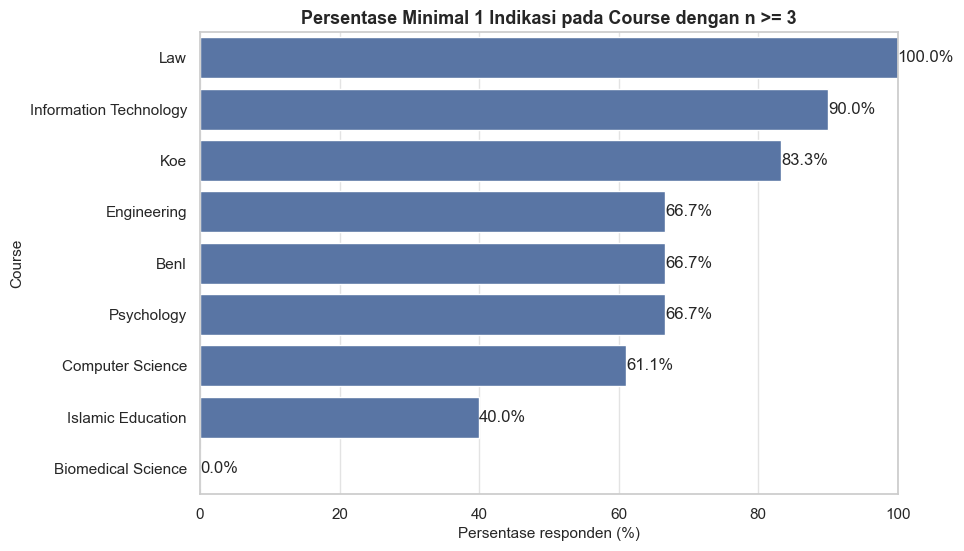

In [55]:
min_n = 3
course_issue_summary = (
    df_clean
    .groupby('course_clean', observed=True)
    .agg(
        total=('course_clean', 'size'),
        with_any_issue=('has_any_issue', 'sum'),
        silent_struggle=('support_status', lambda s: (s == 'Silent Struggle').sum()),
        avg_issue_count=('issue_count', 'mean')
    )
    .reset_index()
)
course_issue_summary['any_issue_pct'] = (course_issue_summary['with_any_issue'] / course_issue_summary['total'] * 100).round(2)
course_issue_summary['silent_struggle_pct'] = (course_issue_summary['silent_struggle'] / course_issue_summary['total'] * 100).round(2)
course_issue_summary['avg_issue_count'] = course_issue_summary['avg_issue_count'].round(2)

course_issue_filtered = course_issue_summary[course_issue_summary['total'] >= min_n].sort_values(
    ['any_issue_pct', 'total'], ascending=[False, False]
)

display(course_issue_filtered)

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=course_issue_filtered, y='course_clean', x='any_issue_pct', color='#4C72B0')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title(f'Persentase Minimal 1 Indikasi pada Course dengan n >= {min_n}')
plt.xlabel('Persentase responden (%)')
plt.ylabel('Course')
plt.xlim(0, 100)
plt.show()

## 15. Analisis Hubungan Sederhana antar Variabel Kategorikal

Bagian ini menggunakan Chi-square dan Cramer's V sebagai ukuran asosiasi sederhana. Hasil ini **bukan bukti kausal**, tetapi bisa membantu menentukan variabel mana yang menarik untuk dianalisis lebih lanjut.

In [56]:
try:
    from scipy.stats import chi2_contingency

    def cramers_v(confusion_matrix):
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        r, k = confusion_matrix.shape
        if n == 0 or min(k - 1, r - 1) == 0:
            return np.nan
        return np.sqrt((chi2 / n) / min(k - 1, r - 1))

    assoc_results = []
    predictors = ['gender', 'year_study', 'cgpa', 'marital_status', 'age_group']
    targets = ['has_any_issue', 'multiple_issue', 'seek_specialist']

    for predictor in predictors:
        for target in targets:
            temp = df_clean[[predictor, target]].dropna()
            ct = pd.crosstab(temp[predictor], temp[target])
            if ct.shape[0] > 1 and ct.shape[1] > 1:
                chi2, p, dof, expected = chi2_contingency(ct)
                assoc_results.append({
                    'predictor': predictor,
                    'target': target,
                    'chi2': round(chi2, 4),
                    'p_value': round(p, 4),
                    'cramers_v': round(cramers_v(ct), 4),
                    'note': 'exploratory only'
                })

    assoc_df = pd.DataFrame(assoc_results).sort_values('cramers_v', ascending=False)
    display(assoc_df)

except Exception as e:
    print('Scipy tidak tersedia atau terjadi error:', e)
    print('Lewati analisis asosiasi statistik.')

,predictor,target,chi2,p_value,cramers_v,note
10,marital_status,multiple_issue,18.50,0.00,0.43,exploratory only
8,cgpa,seek_specialist,17.48,0.00,0.42,exploratory only
9,marital_status,has_any_issue,9.20,0.00,0.30,exploratory only
11,marital_status,seek_specialist,8.64,0.00,0.29,exploratory only
3,year_study,has_any_issue,8.03,0.05,0.28,exploratory only
7,cgpa,multiple_issue,6.91,0.14,0.26,exploratory only
6,cgpa,has_any_issue,3.01,0.56,0.17,exploratory only
13,age_group,multiple_issue,2.65,0.45,0.16,exploratory only
4,year_study,multiple_issue,1.09,0.78,0.10,exploratory only
14,age_group,seek_specialist,0.92,0.82,0.10,exploratory only


## 16. Key Insights Otomatis dari Dataset

Cell berikut merangkum insight utama yang bisa langsung dijadikan bahan Bab 5 worksheet.

In [57]:
# Ambil beberapa angka utama untuk narasi insight
n = len(df_clean)
with_issue = int(df_clean['has_any_issue'].sum())
with_issue_pct = with_issue / n * 100
silent_struggle = int((df_clean['support_status'] == 'Silent Struggle').sum())
silent_struggle_pct_total = silent_struggle / n * 100
silent_struggle_pct_at_risk = silent_struggle / with_issue * 100 if with_issue else 0
reached_support = int((df_clean['support_status'] == 'Reached Support').sum())
multiple_issue = int(df_clean['multiple_issue'].sum())
multiple_issue_pct = multiple_issue / n * 100
all_three = int(df_clean['all_three_issues'].sum())
all_three_pct = all_three / n * 100

# Tahun studi dengan persentase indikasi tertinggi, syarat minimal n>=5 agar tidak terlalu misleading
year_valid = year_summary[year_summary['total'] >= 5]
top_year = year_valid.sort_values('any_issue_pct', ascending=False).iloc[0]

# CGPA dengan n terbesar dan gambaran umum
cgpa_valid = cgpa_summary[cgpa_summary['total'] >= 5]
top_cgpa = cgpa_valid.sort_values('any_issue_pct', ascending=False).iloc[0]

insight_text = f'''
### Ringkasan Insight Utama

1. Dari total **{n}** responden, terdapat **{with_issue} responden ({with_issue_pct:.1f}%)** yang memiliki minimal satu indikasi mental health, yaitu depression, anxiety, atau panic attack.

2. Dari kelompok yang memiliki indikasi tersebut, sebanyak **{silent_struggle} responden** belum mencari bantuan profesional. Artinya, **{silent_struggle_pct_at_risk:.1f}%** responden yang berisiko masih berada dalam kondisi *silent struggle*.

3. Terdapat **{multiple_issue} responden ({multiple_issue_pct:.1f}%)** yang memiliki dua atau lebih indikasi sekaligus, dan **{all_three} responden ({all_three_pct:.1f}%)** melaporkan depression, anxiety, dan panic attack secara bersamaan.

4. Berdasarkan tahun studi, kelompok **{top_year['year_study']}** memiliki persentase minimal satu indikasi tertinggi pada dataset, yaitu **{top_year['any_issue_pct']:.1f}%** dari **{int(top_year['total'])}** responden di kelompok tersebut. Namun, hasil ini tetap perlu dibaca sebagai eksplorasi awal karena ukuran dataset relatif kecil.

5. Berdasarkan CGPA, kelompok **{top_cgpa['cgpa']}** memiliki persentase minimal satu indikasi tertinggi pada kelompok dengan jumlah data memadai, yaitu **{top_cgpa['any_issue_pct']:.1f}%**. Insight pentingnya: kondisi mental mahasiswa tidak bisa hanya dinilai dari performa akademik.

6. Dataset menunjukkan bahwa isu utama bukan hanya keberadaan indikasi mental health, tetapi juga rendahnya keterhubungan mahasiswa dengan bantuan profesional. Ini mendukung kebutuhan sistem Smart Campus yang lebih proaktif, bukan hanya layanan konseling pasif.
'''

display(Markdown(insight_text))


### Ringkasan Insight Utama

1. Dari total **101** responden, terdapat **64 responden (63.4%)** yang memiliki minimal satu indikasi mental health, yaitu depression, anxiety, atau panic attack.

2. Dari kelompok yang memiliki indikasi tersebut, sebanyak **58 responden** belum mencari bantuan profesional. Artinya, **90.6%** responden yang berisiko masih berada dalam kondisi *silent struggle*.

3. Terdapat **28 responden (27.7%)** yang memiliki dua atau lebih indikasi sekaligus, dan **10 responden (9.9%)** melaporkan depression, anxiety, dan panic attack secara bersamaan.

4. Berdasarkan tahun studi, kelompok **Year 3** memiliki persentase minimal satu indikasi tertinggi pada dataset, yaitu **75.0%** dari **24** responden di kelompok tersebut. Namun, hasil ini tetap perlu dibaca sebagai eksplorasi awal karena ukuran dataset relatif kecil.

5. Berdasarkan CGPA, kelompok **3.00 - 3.49** memiliki persentase minimal satu indikasi tertinggi pada kelompok dengan jumlah data memadai, yaitu **65.1%**. Insight pentingnya: kondisi mental mahasiswa tidak bisa hanya dinilai dari performa akademik.

6. Dataset menunjukkan bahwa isu utama bukan hanya keberadaan indikasi mental health, tetapi juga rendahnya keterhubungan mahasiswa dengan bantuan profesional. Ini mendukung kebutuhan sistem Smart Campus yang lebih proaktif, bukan hanya layanan konseling pasif.


## 17. Rekomendasi untuk Smart Campus

Berdasarkan hasil analisis, solusi yang dapat dikembangkan bukan harus langsung berupa sistem diagnosis, tetapi bisa berupa **dashboard analitik dan early support monitoring** untuk membantu kampus memahami pola kesejahteraan mahasiswa secara agregat dan aman.

### Rekomendasi Implementasi

1. **Dashboard Mental Health Support Gap**  
   Dashboard menampilkan data agregat seperti persentase responden dengan indikasi mental health, jumlah silent struggle, tren berdasarkan tahun studi, CGPA, dan kategori lain. Data harus dibuat anonim dan hanya digunakan untuk kebijakan pendampingan.

2. **Proactive Outreach berbasis Segmentasi Risiko**  
   Kampus dapat mengembangkan mekanisme pendekatan yang lebih proaktif, misalnya kampanye konsultasi, check-in berkala, atau edukasi mental health pada kelompok yang memiliki support gap tinggi.

3. **Integrasi Data dengan Layanan Konseling Kampus**  
   Sistem dapat menjadi alat bantu bagi unit konseling untuk membaca kebutuhan layanan, bukan untuk menggantikan konselor. Output sistem sebaiknya berupa prioritas pendampingan, bukan diagnosis.

4. **Program Khusus berdasarkan Fase Studi**  
   Jika kelompok tahun tertentu menunjukkan indikator lebih tinggi, kampus dapat menyesuaikan program, misalnya sesi adaptasi akademik untuk mahasiswa awal atau manajemen burnout untuk tahun tengah/akhir.

5. **Perbaikan Tata Kelola Data**  
   Data perlu distandardisasi, dilengkapi, dan dikelola dengan prinsip privasi. Untuk implementasi nyata, data survei sebaiknya dikombinasikan dengan data akademik, layanan konseling, dan aktivitas kampus secara etis.

### Batasan Analisis

- Dataset berukuran kecil sehingga hasil belum dapat digeneralisasi ke seluruh mahasiswa UB.
- Data bersifat self-reported, sehingga dapat dipengaruhi bias jawaban responden.
- Analisis ini tidak membuktikan hubungan sebab-akibat.
- Hasil analisis tidak boleh digunakan untuk diagnosis medis.
- Implementasi nyata wajib memperhatikan informed consent, anonimisasi data, keamanan data, dan keterlibatan profesional psikologi/konseling.

## 18. Export Data Hasil Cleaning dan Tabel Ringkasan

Cell ini menyimpan dataset bersih dan beberapa tabel ringkasan. File ini bisa dipakai untuk lampiran, dashboard sederhana, atau bahan visualisasi lanjutan.

In [58]:
output_dir = Path('./outputs')
output_dir.mkdir(exist_ok=True)

df_clean.to_csv(output_dir / 'student_mental_health_cleaned.csv', index=False)
indicator_summary.to_csv(output_dir / 'indicator_summary.csv', index=False)
issue_count_summary.to_csv(output_dir / 'issue_count_summary.csv', index=False)
combination_summary.to_csv(output_dir / 'combination_summary.csv', index=False)
support_status_summary.to_csv(output_dir / 'support_status_summary.csv', index=False)
year_summary.to_csv(output_dir / 'year_summary.csv', index=False)
cgpa_summary.to_csv(output_dir / 'cgpa_summary.csv', index=False)
gender_summary.to_csv(output_dir / 'gender_summary.csv', index=False)
age_summary.to_csv(output_dir / 'age_summary.csv', index=False)
course_issue_summary.to_csv(output_dir / 'course_issue_summary.csv', index=False)

print('Export selesai. File tersimpan di folder outputs/:')
for file in output_dir.glob('*.csv'):
    print('-', file)

Export selesai. File tersimpan di folder outputs/:
- outputs\age_summary.csv
- outputs\cgpa_summary.csv
- outputs\combination_summary.csv
- outputs\course_issue_summary.csv
- outputs\gender_summary.csv
- outputs\indicator_summary.csv
- outputs\issue_count_summary.csv
- outputs\student_mental_health_cleaned.csv
- outputs\support_status_summary.csv
- outputs\year_summary.csv



## 19. Visualisasi Presentation-Ready

Bagian ini menambahkan visualisasi yang lebih menarik untuk kebutuhan presentasi, worksheet, dan lampiran. Fokusnya adalah membuat insight utama lebih cepat terbaca oleh juri: **prevalensi indikasi mental health**, **support gap**, **co-occurrence gejala**, dan **pola berdasarkan tahun studi/CGPA**.

Seluruh gambar pada bagian ini juga disimpan otomatis ke folder `outputs/visualizations/` agar bisa langsung dipakai di laporan atau slide.


In [59]:

# Setup visual style agar grafik lebih presentation-ready
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mtick

viz_dir = Path('./outputs/visualizations')
viz_dir.mkdir(parents=True, exist_ok=True)

COLORS = {
    'text': '#0F172A',
    'muted': '#64748B',
    'grid': '#E2E8F0',
    'blue': '#2563EB',
    'cyan': '#0891B2',
    'green': '#16A34A',
    'orange': '#F97316',
    'red': '#DC2626',
    'purple': '#7C3AED',
    'gray': '#CBD5E1',
    'light_gray': '#F1F5F9'
}

status_order = ['Stable / No Reported Indicator', 'Silent Struggle', 'Reached Support']
status_palette = {
    'Stable / No Reported Indicator': COLORS['blue'],
    'Silent Struggle': COLORS['red'],
    'Reached Support': COLORS['green']
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': COLORS['grid'],
    'axes.labelcolor': COLORS['text'],
    'xtick.color': COLORS['muted'],
    'ytick.color': COLORS['muted'],
    'text.color': COLORS['text'],
    'axes.titleweight': 'bold',
    'axes.titlesize': 15,
    'axes.labelsize': 11,
    'font.size': 10,
    'grid.color': COLORS['grid'],
    'grid.alpha': 0.55,
})
sns.set_theme(style='whitegrid')


def save_viz(filename):
    # Simpan visualisasi dengan resolusi tinggi.
    plt.tight_layout()
    plt.savefig(viz_dir / filename, dpi=220, bbox_inches='tight', facecolor='white')
    plt.show()


def clean_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(COLORS['grid'])
    ax.spines['bottom'].set_color(COLORS['grid'])
    return ax


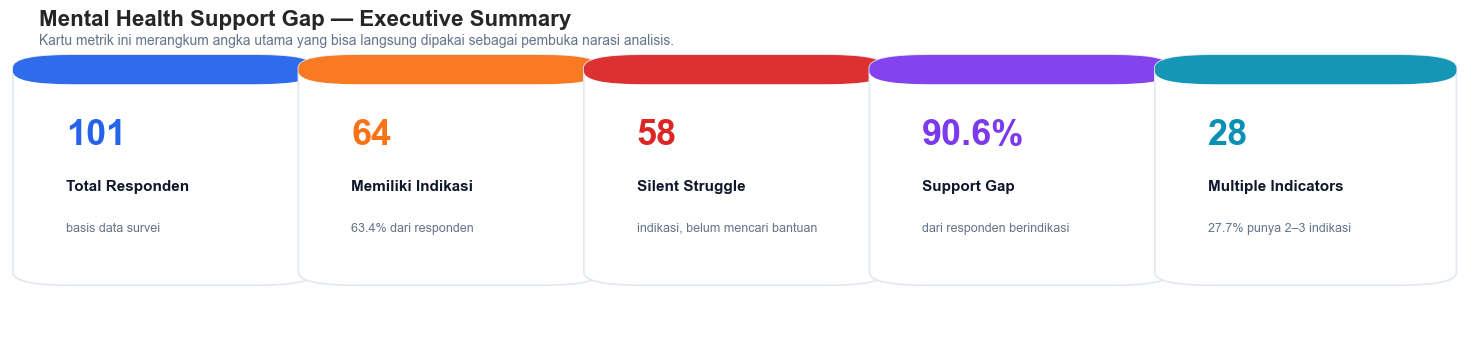

In [60]:

# KPI Cards — ringkasan angka utama yang cocok untuk pembuka presentasi
n = len(df_clean)
with_issue = int(df_clean['has_any_issue'].sum())
with_issue_pct = with_issue / n * 100
silent_struggle = int((df_clean['support_status'] == 'Silent Struggle').sum())
reached_support = int((df_clean['support_status'] == 'Reached Support').sum())
support_gap_pct = silent_struggle / with_issue * 100 if with_issue else 0
multiple_issue = int(df_clean['multiple_issue'].sum())
multiple_issue_pct = multiple_issue / n * 100

kpi_items = [
    ('Total Responden', f'{n}', 'basis data survei', COLORS['blue']),
    ('Memiliki Indikasi', f'{with_issue}', f'{with_issue_pct:.1f}% dari responden', COLORS['orange']),
    ('Silent Struggle', f'{silent_struggle}', 'indikasi, belum mencari bantuan', COLORS['red']),
    ('Support Gap', f'{support_gap_pct:.1f}%', 'dari responden berindikasi', COLORS['purple']),
    ('Multiple Indicators', f'{multiple_issue}', f'{multiple_issue_pct:.1f}% punya 2–3 indikasi', COLORS['cyan'])
]

fig, ax = plt.subplots(figsize=(15, 3.6))
ax.axis('off')

for i, (title, value, subtitle, color) in enumerate(kpi_items):
    x = 0.02 + i * 0.195
    y = 0.16
    w = 0.17
    h = 0.68
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.018,rounding_size=0.04',
        linewidth=1.2,
        edgecolor='#E2E8F0',
        facecolor='white'
    )
    ax.add_patch(box)
    ax.add_patch(FancyBboxPatch(
        (x, y + h - 0.055), w, 0.055,
        boxstyle='round,pad=0.018,rounding_size=0.04',
        linewidth=0,
        facecolor=color,
        alpha=0.95
    ))
    ax.text(x + 0.018, y + 0.45, value, fontsize=26, fontweight='bold', color=color, va='center')
    ax.text(x + 0.018, y + 0.29, title, fontsize=11, fontweight='bold', color=COLORS['text'], va='center')
    ax.text(x + 0.018, y + 0.16, subtitle, fontsize=9, color=COLORS['muted'], va='center')

ax.text(0.02, 0.95, 'Mental Health Support Gap — Executive Summary', fontsize=16, fontweight='bold')
ax.text(0.02, 0.89, 'Kartu metrik ini merangkum angka utama yang bisa langsung dipakai sebagai pembuka narasi analisis.', fontsize=10, color=COLORS['muted'])

save_viz('01_kpi_cards_support_gap.png')


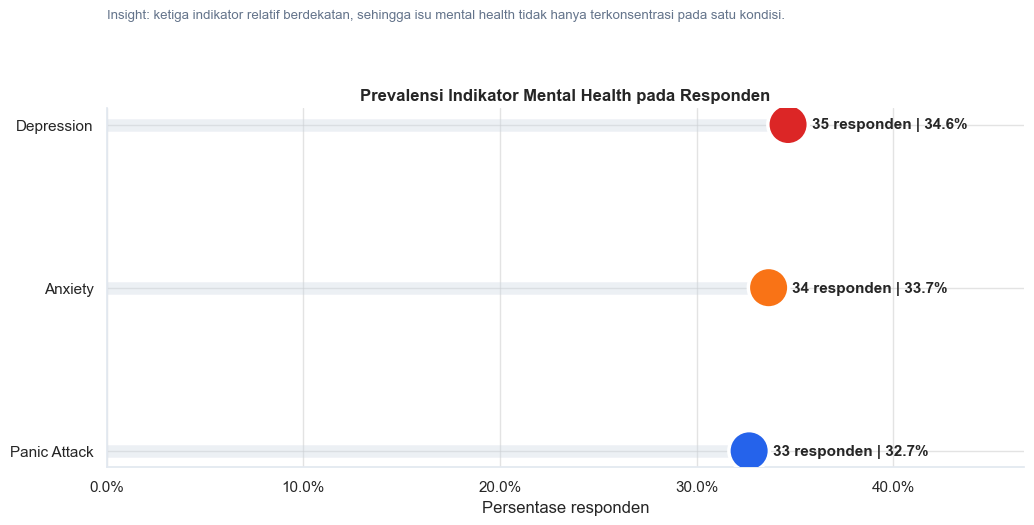

In [61]:

# Lollipop Chart — prevalensi tiap indikator mental health
indicator_plot = indicator_summary.copy()
indicator_plot['label'] = indicator_plot.apply(
    lambda r: f"{int(r['count_yes'])} responden | {r['percentage_yes']:.1f}%", axis=1
)
indicator_plot = indicator_plot.sort_values('percentage_yes')

fig, ax = plt.subplots(figsize=(10.5, 5.6))
y_pos = np.arange(len(indicator_plot))
colors = [COLORS['blue'], COLORS['orange'], COLORS['red']]

ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=indicator_plot['percentage_yes'],
    color=COLORS['gray'],
    linewidth=9,
    alpha=0.35
)
ax.scatter(
    indicator_plot['percentage_yes'],
    y_pos,
    s=850,
    color=colors[:len(indicator_plot)],
    edgecolor='white',
    linewidth=2.5,
    zorder=3
)

for i, row in enumerate(indicator_plot.itertuples()):
    ax.text(row.percentage_yes + 1.2, i, row.label, va='center', fontsize=11, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(indicator_plot['indicator'])
ax.set_xlim(0, max(45, indicator_plot['percentage_yes'].max() + 12))
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Persentase responden')
ax.set_title('Prevalensi Indikator Mental Health pada Responden')
ax.text(0, len(indicator_plot) - 0.35, 'Insight: ketiga indikator relatif berdekatan, sehingga isu mental health tidak hanya terkonsentrasi pada satu kondisi.', fontsize=9.5, color=COLORS['muted'])
clean_axis(ax)
save_viz('02_lollipop_prevalensi_indikator.png')


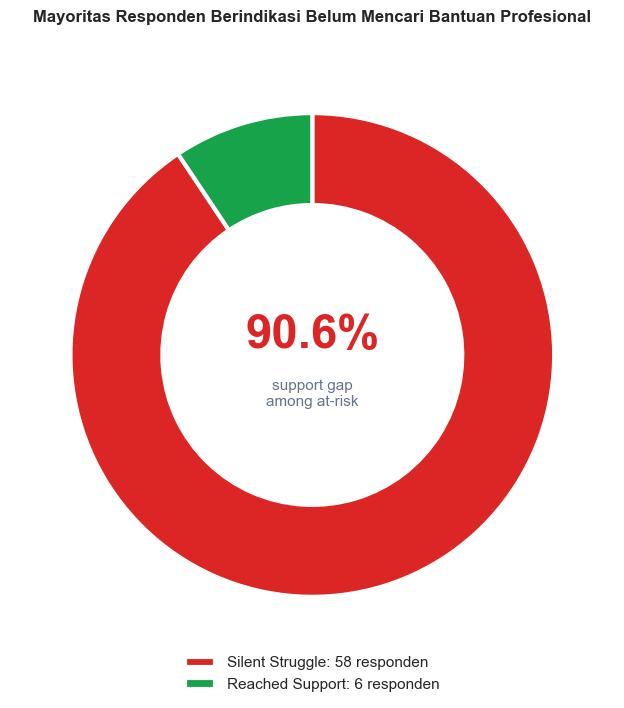

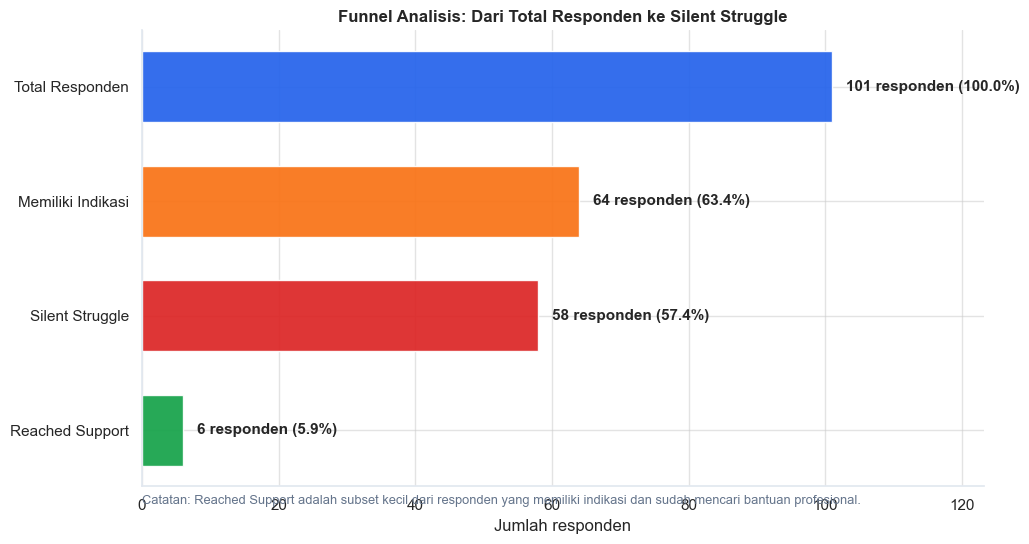

In [62]:

# Donut Chart — Support Gap pada kelompok responden yang memiliki indikasi
at_risk_counts = pd.Series({
    'Silent Struggle': silent_struggle,
    'Reached Support': reached_support
})

fig, ax = plt.subplots(figsize=(7.5, 7.2))
wedges, _ = ax.pie(
    at_risk_counts.values,
    startangle=90,
    counterclock=False,
    colors=[COLORS['red'], COLORS['green']],
    wedgeprops={'width': 0.38, 'edgecolor': 'white', 'linewidth': 3}
)
ax.text(0, 0.08, f'{support_gap_pct:.1f}%', ha='center', va='center', fontsize=34, fontweight='bold', color=COLORS['red'])
ax.text(0, -0.16, 'support gap\namong at-risk', ha='center', va='center', fontsize=11, color=COLORS['muted'])
ax.set_title('Mayoritas Responden Berindikasi Belum Mencari Bantuan Profesional', pad=22)
ax.legend(
    wedges,
    [f'{idx}: {val} responden' for idx, val in at_risk_counts.items()],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=1,
    frameon=False
)
save_viz('03_donut_support_gap.png')

# Funnel sederhana — dari total responden hingga kelompok silent struggle
funnel_df = pd.DataFrame({
    'stage': ['Total Responden', 'Memiliki Indikasi', 'Silent Struggle', 'Reached Support'],
    'count': [n, with_issue, silent_struggle, reached_support],
    'color': [COLORS['blue'], COLORS['orange'], COLORS['red'], COLORS['green']]
})

fig, ax = plt.subplots(figsize=(10.5, 5.6))
y = np.arange(len(funnel_df))
ax.barh(y, funnel_df['count'], color=funnel_df['color'], alpha=0.93, height=0.62)
for i, row in enumerate(funnel_df.itertuples()):
    pct_total = row.count / n * 100
    ax.text(row.count + 2, i, f'{row.count} responden ({pct_total:.1f}%)', va='center', fontsize=11, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(funnel_df['stage'])
ax.invert_yaxis()
ax.set_xlim(0, max(funnel_df['count']) * 1.22)
ax.set_xlabel('Jumlah responden')
ax.set_title('Funnel Analisis: Dari Total Responden ke Silent Struggle')
ax.text(0, 3.65, 'Catatan: Reached Support adalah subset kecil dari responden yang memiliki indikasi dan sudah mencari bantuan profesional.', fontsize=9.3, color=COLORS['muted'])
clean_axis(ax)
save_viz('04_funnel_silent_struggle.png')


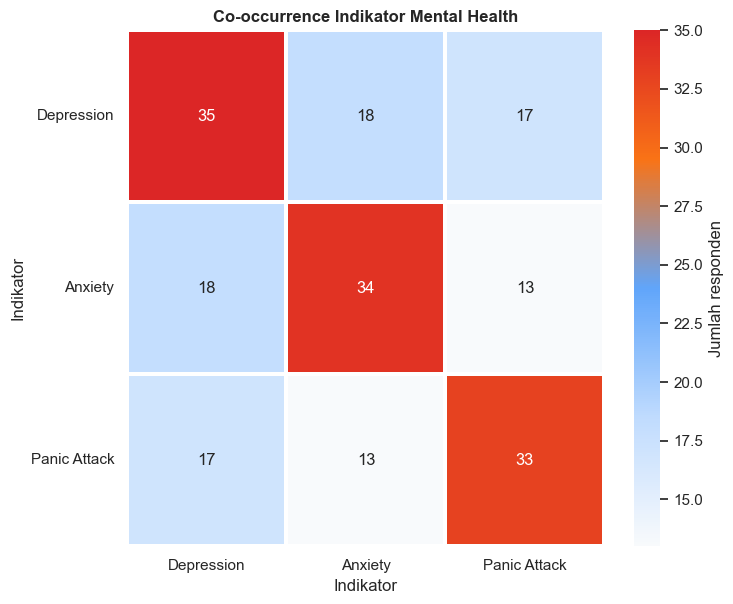

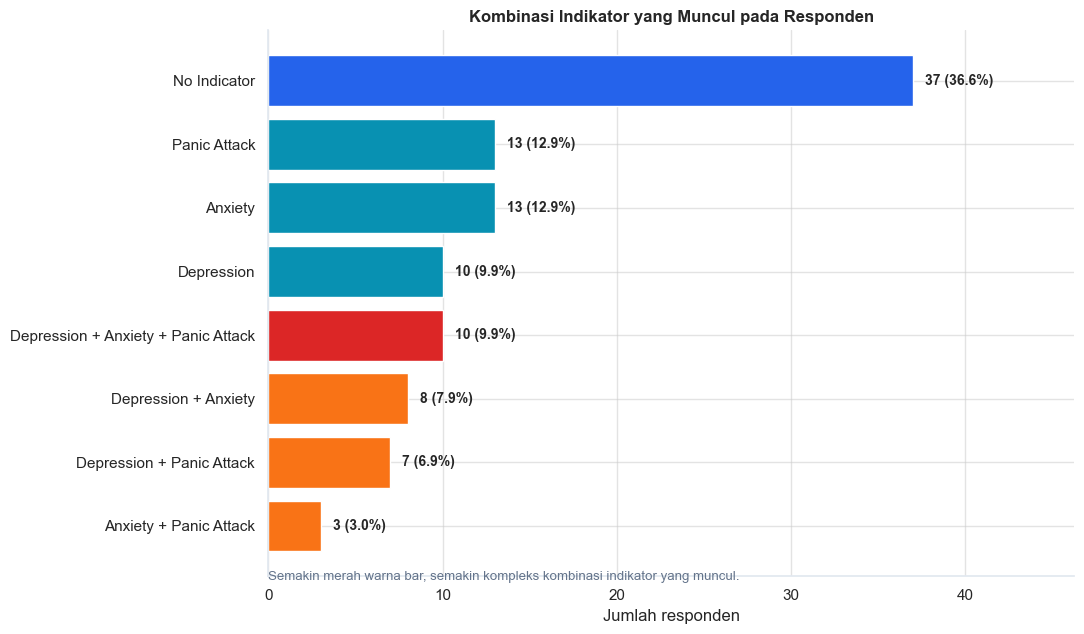

In [63]:

# Co-occurrence Heatmap — seberapa sering indikator muncul bersamaan
issue_names = ['Depression', 'Anxiety', 'Panic Attack']
issue_cols = ['depression', 'anxiety', 'panic_attack']
co_matrix = pd.DataFrame(index=issue_names, columns=issue_names, dtype=int)

for i, col_i in enumerate(issue_cols):
    for j, col_j in enumerate(issue_cols):
        if i == j:
            co_matrix.iloc[i, j] = int(df_clean[col_i].sum())
        else:
            co_matrix.iloc[i, j] = int(((df_clean[col_i] == 1) & (df_clean[col_j] == 1)).sum())

mental_cmap = LinearSegmentedColormap.from_list('mental_cmap', ['#F8FAFC', '#BFDBFE', '#60A5FA', '#F97316', '#DC2626'])
fig, ax = plt.subplots(figsize=(7.5, 6.2))
sns.heatmap(
    co_matrix,
    annot=True,
    fmt='.0f',
    cmap=mental_cmap,
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'label': 'Jumlah responden'},
    ax=ax
)
ax.set_title('Co-occurrence Indikator Mental Health')
ax.set_xlabel('Indikator')
ax.set_ylabel('Indikator')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
save_viz('05_heatmap_cooccurrence_indikator.png')

# Bar chart kombinasi indikator — lebih informatif daripada menghitung satu per satu
comb_plot = combination_summary.copy()
comb_plot['issue_count_visual'] = comb_plot['combination'].apply(lambda x: 0 if x == 'No Indicator' else x.count('+') + 1)
comb_plot = comb_plot.sort_values('count', ascending=True)
combo_colors = comb_plot['issue_count_visual'].map({
    0: COLORS['blue'],
    1: COLORS['cyan'],
    2: COLORS['orange'],
    3: COLORS['red']
})

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(comb_plot['combination'], comb_plot['count'], color=combo_colors)
for i, row in enumerate(comb_plot.itertuples()):
    ax.text(row.count + 0.7, i, f'{row.count} ({row.percentage:.1f}%)', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, comb_plot['count'].max() * 1.25)
ax.set_xlabel('Jumlah responden')
ax.set_title('Kombinasi Indikator yang Muncul pada Responden')
ax.text(0, -0.85, 'Semakin merah warna bar, semakin kompleks kombinasi indikator yang muncul.', fontsize=9.5, color=COLORS['muted'])
clean_axis(ax)
save_viz('06_bar_kombinasi_indikator.png')


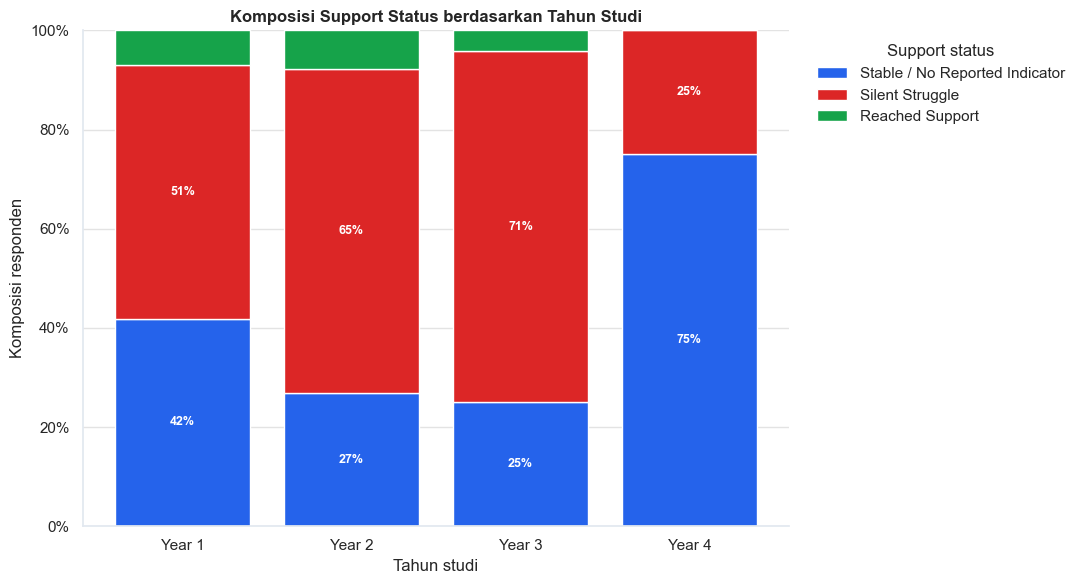

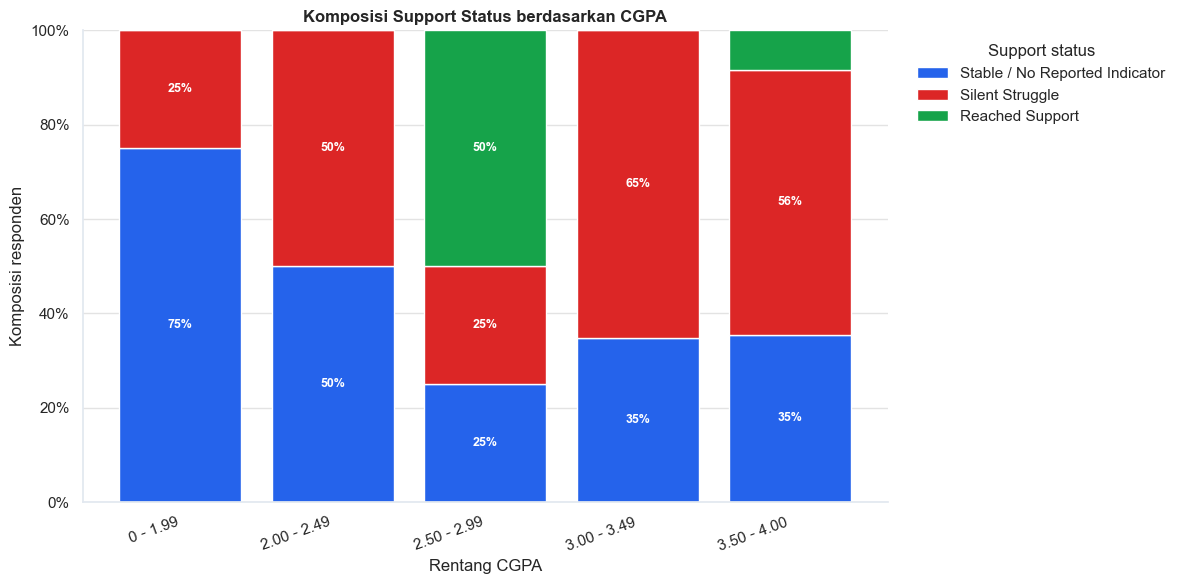

In [64]:

# 100% Stacked Bar — komposisi support status berdasarkan tahun studi
status_count_year = pd.crosstab(df_clean['year_study'], df_clean['support_status']).reindex(columns=status_order, fill_value=0)
status_pct_year = status_count_year.div(status_count_year.sum(axis=1), axis=0).mul(100).fillna(0)

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(status_pct_year))
for status in status_order:
    values = status_pct_year[status].values
    bars = ax.bar(status_pct_year.index.astype(str), values, bottom=bottom, label=status, color=status_palette[status])
    for bar, val, base in zip(bars, values, bottom):
        if val >= 9:
            ax.text(bar.get_x() + bar.get_width()/2, base + val/2, f'{val:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += values
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Tahun studi')
ax.set_ylabel('Komposisi responden')
ax.set_title('Komposisi Support Status berdasarkan Tahun Studi')
ax.legend(title='Support status', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
clean_axis(ax)
save_viz('07_stacked_support_status_tahun_studi.png')

# 100% Stacked Bar — komposisi support status berdasarkan CGPA
status_count_cgpa = pd.crosstab(df_clean['cgpa'], df_clean['support_status']).reindex(columns=status_order, fill_value=0)
status_pct_cgpa = status_count_cgpa.div(status_count_cgpa.sum(axis=1), axis=0).mul(100).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(status_pct_cgpa))
for status in status_order:
    values = status_pct_cgpa[status].values
    bars = ax.bar(status_pct_cgpa.index.astype(str), values, bottom=bottom, label=status, color=status_palette[status])
    for bar, val, base in zip(bars, values, bottom):
        if val >= 9:
            ax.text(bar.get_x() + bar.get_width()/2, base + val/2, f'{val:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += values
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Rentang CGPA')
ax.set_ylabel('Komposisi responden')
ax.set_title('Komposisi Support Status berdasarkan CGPA')
plt.xticks(rotation=20, ha='right')
ax.legend(title='Support status', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
clean_axis(ax)
save_viz('08_stacked_support_status_cgpa.png')


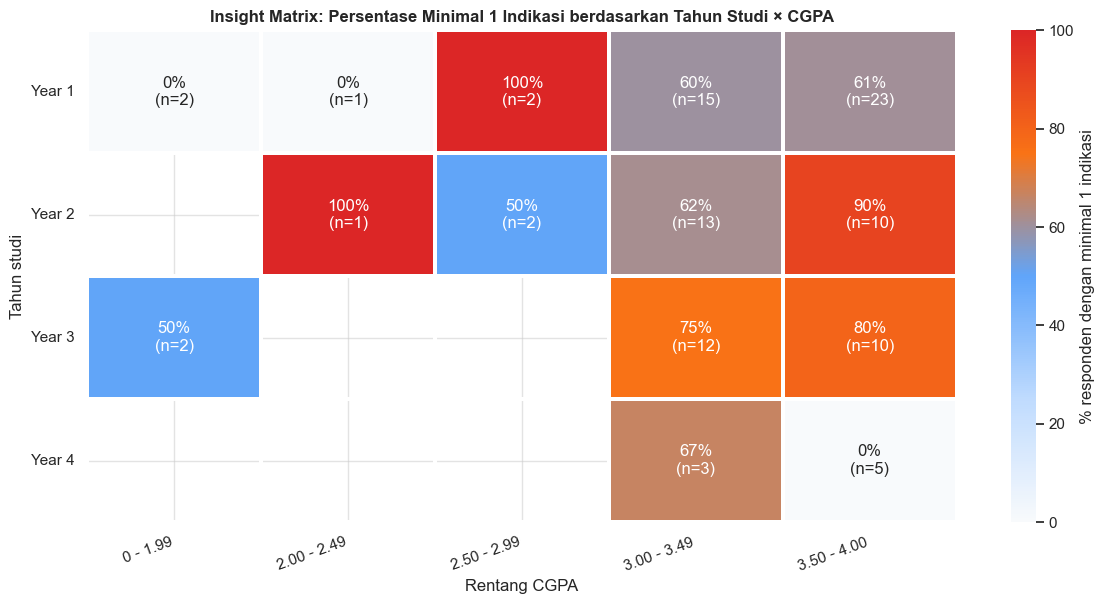

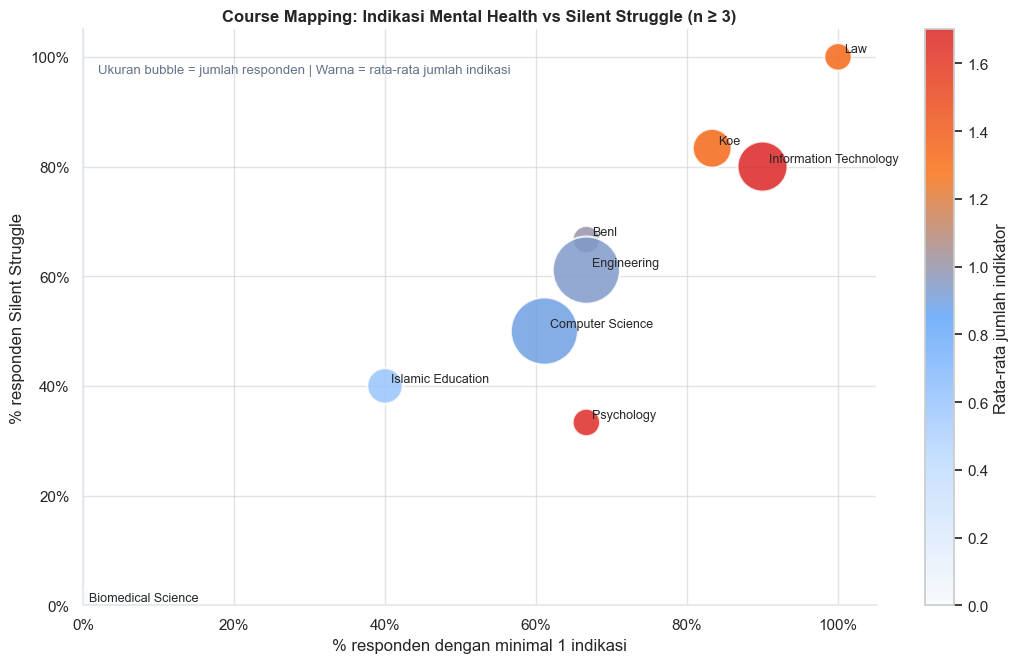

In [65]:

# Insight Matrix — persentase minimal 1 indikasi berdasarkan kombinasi tahun studi dan CGPA
risk_matrix = pd.pivot_table(
    df_clean,
    values='has_any_issue',
    index='year_study',
    columns='cgpa',
    aggfunc='mean',
    observed=True
).mul(100)

count_matrix = pd.pivot_table(
    df_clean,
    values='has_any_issue',
    index='year_study',
    columns='cgpa',
    aggfunc='count',
    observed=True
)

annot_matrix = risk_matrix.copy().astype(object)
for idx in risk_matrix.index:
    for col in risk_matrix.columns:
        val = risk_matrix.loc[idx, col]
        count = count_matrix.loc[idx, col]
        if pd.isna(val):
            annot_matrix.loc[idx, col] = ''
        else:
            annot_matrix.loc[idx, col] = f'{val:.0f}%\n(n={int(count)})'

fig, ax = plt.subplots(figsize=(12, 6.2))
sns.heatmap(
    risk_matrix,
    annot=annot_matrix,
    fmt='',
    cmap=mental_cmap,
    vmin=0,
    vmax=100,
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'label': '% responden dengan minimal 1 indikasi'},
    ax=ax
)
ax.set_title('Insight Matrix: Persentase Minimal 1 Indikasi berdasarkan Tahun Studi × CGPA')
ax.set_xlabel('Rentang CGPA')
ax.set_ylabel('Tahun studi')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
save_viz('09_heatmap_tahun_cgpa_any_issue.png')

# Course Bubble Chart — fokus course dengan jumlah responden memadai
course_bubble = course_issue_summary[course_issue_summary['total'] >= min_n].copy()
course_bubble = course_bubble.sort_values('silent_struggle_pct', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 6.8))
scatter = ax.scatter(
    course_bubble['any_issue_pct'],
    course_bubble['silent_struggle_pct'],
    s=course_bubble['total'] * 130,
    c=course_bubble['avg_issue_count'],
    cmap=mental_cmap,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.5
)
for row in course_bubble.itertuples():
    ax.text(row.any_issue_pct + 0.8, row.silent_struggle_pct + 0.8, row.course_clean, fontsize=9)
ax.set_xlim(0, 105)
ax.set_ylim(0, 105)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('% responden dengan minimal 1 indikasi')
ax.set_ylabel('% responden Silent Struggle')
ax.set_title(f'Course Mapping: Indikasi Mental Health vs Silent Struggle (n ≥ {min_n})')
ax.text(2, 97, 'Ukuran bubble = jumlah responden | Warna = rata-rata jumlah indikasi', fontsize=9.5, color=COLORS['muted'])
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Rata-rata jumlah indikator')
clean_axis(ax)
save_viz('10_bubble_course_mapping.png')


In [ ]:

# Daftar file visualisasi yang berhasil dibuat
viz_files = sorted(viz_dir.glob('*.png'))
print('Visualisasi presentation-ready tersimpan di:')
print(viz_dir)
print('\nDaftar file:')
for file in viz_files:
    print('-', file.name)


Visualisasi presentation-ready tersimpan di:
outputs\visualizations

Daftar file:
- 01_kpi_cards_support_gap.png
- 02_lollipop_prevalensi_indikator.png
- 03_donut_support_gap.png
- 04_funnel_silent_struggle.png
- 05_heatmap_cooccurrence_indikator.png
- 06_bar_kombinasi_indikator.png
- 07_stacked_support_status_tahun_studi.png
- 08_stacked_support_status_cgpa.png
- 09_heatmap_tahun_cgpa_any_issue.png
- 10_bubble_course_mapping.png


## 20. Gallery Visualisasi Exported

Bagian ini menampilkan file PNG yang sudah diekspor ke folder `outputs/visualizations/`. Saat notebook dibuka dari file ZIP, visualisasi berikut bisa langsung terlihat tanpa harus menjalankan ulang semua cell.

### KPI Cards Support Gap

![KPI Cards Support Gap](outputs/visualizations/01_kpi_cards_support_gap.png)

### Prevalensi Indikator Mental Health

![Prevalensi Indikator Mental Health](outputs/visualizations/02_lollipop_prevalensi_indikator.png)

### Donut Chart Support Gap

![Donut Chart Support Gap](outputs/visualizations/03_donut_support_gap.png)

### Funnel Silent Struggle

![Funnel Silent Struggle](outputs/visualizations/04_funnel_silent_struggle.png)

### Heatmap Co-occurrence Indikator

![Heatmap Co-occurrence Indikator](outputs/visualizations/05_heatmap_cooccurrence_indikator.png)

### Kombinasi Indikator

![Kombinasi Indikator](outputs/visualizations/06_bar_kombinasi_indikator.png)

### Support Status berdasarkan Tahun Studi

![Support Status berdasarkan Tahun Studi](outputs/visualizations/07_stacked_support_status_tahun_studi.png)

### Support Status berdasarkan CGPA

![Support Status berdasarkan CGPA](outputs/visualizations/08_stacked_support_status_cgpa.png)

### Insight Matrix Tahun Studi × CGPA

![Insight Matrix Tahun Studi × CGPA](outputs/visualizations/09_heatmap_tahun_cgpa_any_issue.png)

### Course Mapping Bubble Chart

![Course Mapping Bubble Chart](outputs/visualizations/10_bubble_course_mapping.png)

